# PeacoQC vignette (Python port)

This notebook is a Python port of the canonical R vignette from the
[saeyslab/PeacoQC](https://github.com/saeyslab/PeacoQC) package. It walks
through the standard pre-processing and quality-control pipeline, parameter
tuning for large datasets, multi-sample reports with `peaco_qc_heatmap`,
and peak-only inspection with `plot_peaco_qc`.

`peacoqc` is a peak-based quality control tool for flow and mass
cytometry data. It identifies and removes events originating from clogs,
speed changes, and other measurement artefacts by splitting a file into
time-ordered bins, detecting density peaks per channel, and flagging bins
whose peak structure deviates from the rest of the run (via an isolation
forest and a MAD criterion).

## What this port does (and does not) mirror

The Python API is a faithful re-implementation of the algorithm, but a
few R idioms do not map 1:1:

* `flowCore::compensate` / `flowCore::estimateLogicle` have no direct
  Python equivalent in this package. The R vignette compensates and
  transforms in-line; here we rely on the pre-compensated/transformed
  fixture `inst/extdata/111_Comp_Trans.fcs` (the same file the upstream
  R test suite uses). Compensation and transformation can be performed
  upstream with [`pytometry`](https://github.com/scverse/pytometry),
  [`FlowKit`](https://github.com/whitews/FlowKit), or
  [`flowutils`](https://github.com/whitews/FlowUtils).
* `save_fcs=TRUE` / `output_directory=...` become explicit
  [`peacoqc.write_fcs`](api/generated/peacoqc.write_fcs.rst) and
  [`peacoqc.plot_peaco_qc`](api/generated/peacoqc.plot_peaco_qc.rst)
  calls on the returned `PeacoQCResult`.
* The R isolation tree is replaced by
  `sklearn.ensemble.IsolationForest`, which is broadly equivalent but
  not bit-identical.


## Installation

```bash
pip install peacoqc                 # core
pip install "peacoqc[fcs]"          # + flowio, needed for write_fcs
pip install "peacoqc[plotting]"     # + seaborn
```

See the [Installation](installation.rst) page for the full list of
extras and development installs.


In [1]:
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # anndata + pytometry emit deprecation noise

import matplotlib.pyplot as plt
import numpy as np

import peacoqc

print("peacoqc version:", peacoqc.__version__)

peacoqc version: 0.1.0


# Standard pre-processing pipeline

The R vignette recommends the following pipeline for flow cytometry
data:

1. Read the FCS file.
2. Remove margin events *before* compensation (so that the raw FCS
   range metadata is still available).
3. Compensate and transform.
4. Run `PeacoQC` with `determine_good_cells="all"`.

Below is the Python equivalent of steps 1–2 on the raw FCS file
`inst/extdata/111.fcs`. Compensation and transformation are delegated
to an upstream tool — for the remainder of the vignette we load the
ready-to-QC fixture `inst/extdata/111_Comp_Trans.fcs`.

The channels we use throughout match the R vignette exactly:
`c(1, 3, 5:14, 18, 21)` in 1-based R indexing, i.e.
`[0, 2, 4..13, 17, 20]` in zero-based Python.

In [2]:
# Locate inst/extdata by walking up from the current working directory.
def _find_extdata(start: Path) -> Path:
    for parent in [start, *start.parents]:
        candidate = parent / "inst" / "extdata"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("inst/extdata not found in any parent of " + str(start))

EXTDATA = _find_extdata(Path.cwd())
RAW_FCS = EXTDATA / "111.fcs"
COMP_TRANS_FCS = EXTDATA / "111_Comp_Trans.fcs"
R_REPORT = EXTDATA / "PeacoQC_report.txt"

assert RAW_FCS.exists(), RAW_FCS
assert COMP_TRANS_FCS.exists(), COMP_TRANS_FCS

# Read the raw (untransformed) FCS file.
raw = peacoqc.read_fcs(str(RAW_FCS))
print("raw.shape =", raw.shape)
print("channels:", list(raw.var_names))

raw.shape = (10000, 22)
channels: ['FSC-A', 'FSC-H', 'SSC-A', 'B710-A', 'B515-A', 'G780-A', 'G710-A', 'G660-A', 'G610-A', 'G560-A', 'R780-A', 'R710-A', 'R660-A', 'V800-A', 'V705-A', 'V655-A', 'V605-A', 'V585-A', 'V565-A', 'V545-A', 'V450-A', 'Time']


In [3]:
# Zero-based Python equivalents of the R vignette's `c(1, 3, 5:14, 18, 21)`.
vignette_channel_idx = [0, 2] + list(range(4, 14)) + [17, 20]
vignette_channels = [raw.var_names[i] for i in vignette_channel_idx]
print("QC channels:", vignette_channels)

# Remove margin events using the raw FCS range metadata. This must be done
# BEFORE compensation in R, so the same rule applies here.
raw_no_margins = peacoqc.remove_margins(raw, channels=vignette_channels)
print(f"after remove_margins: {raw_no_margins.shape}  "
      f"({raw.n_obs - raw_no_margins.n_obs} events removed)")

QC channels: ['FSC-A', 'SSC-A', 'B515-A', 'G780-A', 'G710-A', 'G660-A', 'G610-A', 'G560-A', 'R780-A', 'R710-A', 'R660-A', 'V800-A', 'V585-A', 'V450-A']
after remove_margins: (9619, 22)  (381 events removed)


## Running `peaco_qc`

We now load the compensated + transformed fixture and run the full
pipeline. This is the Python equivalent of

```r
peacoqc_res <- PeacoQC(
    ff=ff, channels=channels,
    determine_good_cells="all",
    save_fcs=TRUE, plot=TRUE,
    output_directory="PeacoQC_Example1")
```

The Python API returns a typed
[`PeacoQCResult`](api/generated/peacoqc.PeacoQCResult.rst) object
instead of implicitly writing files to disk — plotting and FCS output
are explicit steps below.

In [4]:
# Load the pre-compensated / pre-transformed file and rerun channel selection
# against it (the columns are the same as the raw file).
adata = peacoqc.read_fcs(str(COMP_TRANS_FCS))
channels = [adata.var_names[i] for i in vignette_channel_idx]
print("adata.shape =", adata.shape)

# Where we will write the PeacoQC CSV report.
OUTPUT_DIR = Path("PeacoQC_Example1")
OUTPUT_DIR.mkdir(exist_ok=True)
report_path = OUTPUT_DIR / "peacoqc_report.csv"

result = peacoqc.peaco_qc(
    adata,
    channels=channels,
    determine_good_cells="all",
    report_path=str(report_path),
)

print(f"percentage removed : {result.percentage_removed:6.2f}%")
print(f"  IT analysis      : {result.it_percentage}")
print(f"  MAD analysis     : {result.mad_percentage}")
print(f"  consecutive bins : {result.consecutive_percentage}")
print(f"events per bin     : {result.events_per_bin}")
print(f"number of bins     : {result.nr_bins}")

adata.shape = (9617, 22)


percentage removed :  10.40%
  IT analysis      : None
  MAD analysis     : 10.398253093480294
  consecutive bins : 0.0
events per bin     : 500
number of bins     : 38


### Inspecting and persisting the cleaned data

`result.adata` holds the cleaned slice of the input `AnnData` — ready
for downstream [scverse](https://scverse.org) tooling. The
`percentage_removed` / `it_percentage` / `mad_percentage`
/ `consecutive_percentage` fields mirror the corresponding columns in
the R report CSV. A `result.weird_channels` dictionary flags any
channel whose signal is monotonically drifting over time.

In [5]:
clean = result.adata
print("clean.shape =", clean.shape)
print("weird channels:", result.weird_channels)
print("analysis mode:", result.analysis)

# Write the cleaned AnnData back to FCS (requires the [fcs] extra).
fcs_out = OUTPUT_DIR / "111_Comp_Trans_cleaned.fcs"
try:
    peacoqc.write_fcs(clean, str(fcs_out))
    print("wrote", fcs_out)
except ModuleNotFoundError as e:
    print("write_fcs skipped:", e, "(install with pip install 'peacoqc[fcs]')")

clean.shape = (8617, 22)
weird channels: {'increasing': [], 'decreasing': [], 'label': 'No increasing or decreasing effect'}
analysis mode: all
wrote PeacoQC_Example1/111_Comp_Trans_cleaned.fcs


### Diagnostic plot

`plot_peaco_qc` produces the per-sample overview that the R vignette
gets from `PeacoQC(..., plot=TRUE)`: an event-rate histogram at the
top-left and per-channel scatter panels showing the detected peak
trajectories and the bins removed by the IT, MAD, and consecutive-bin
steps.

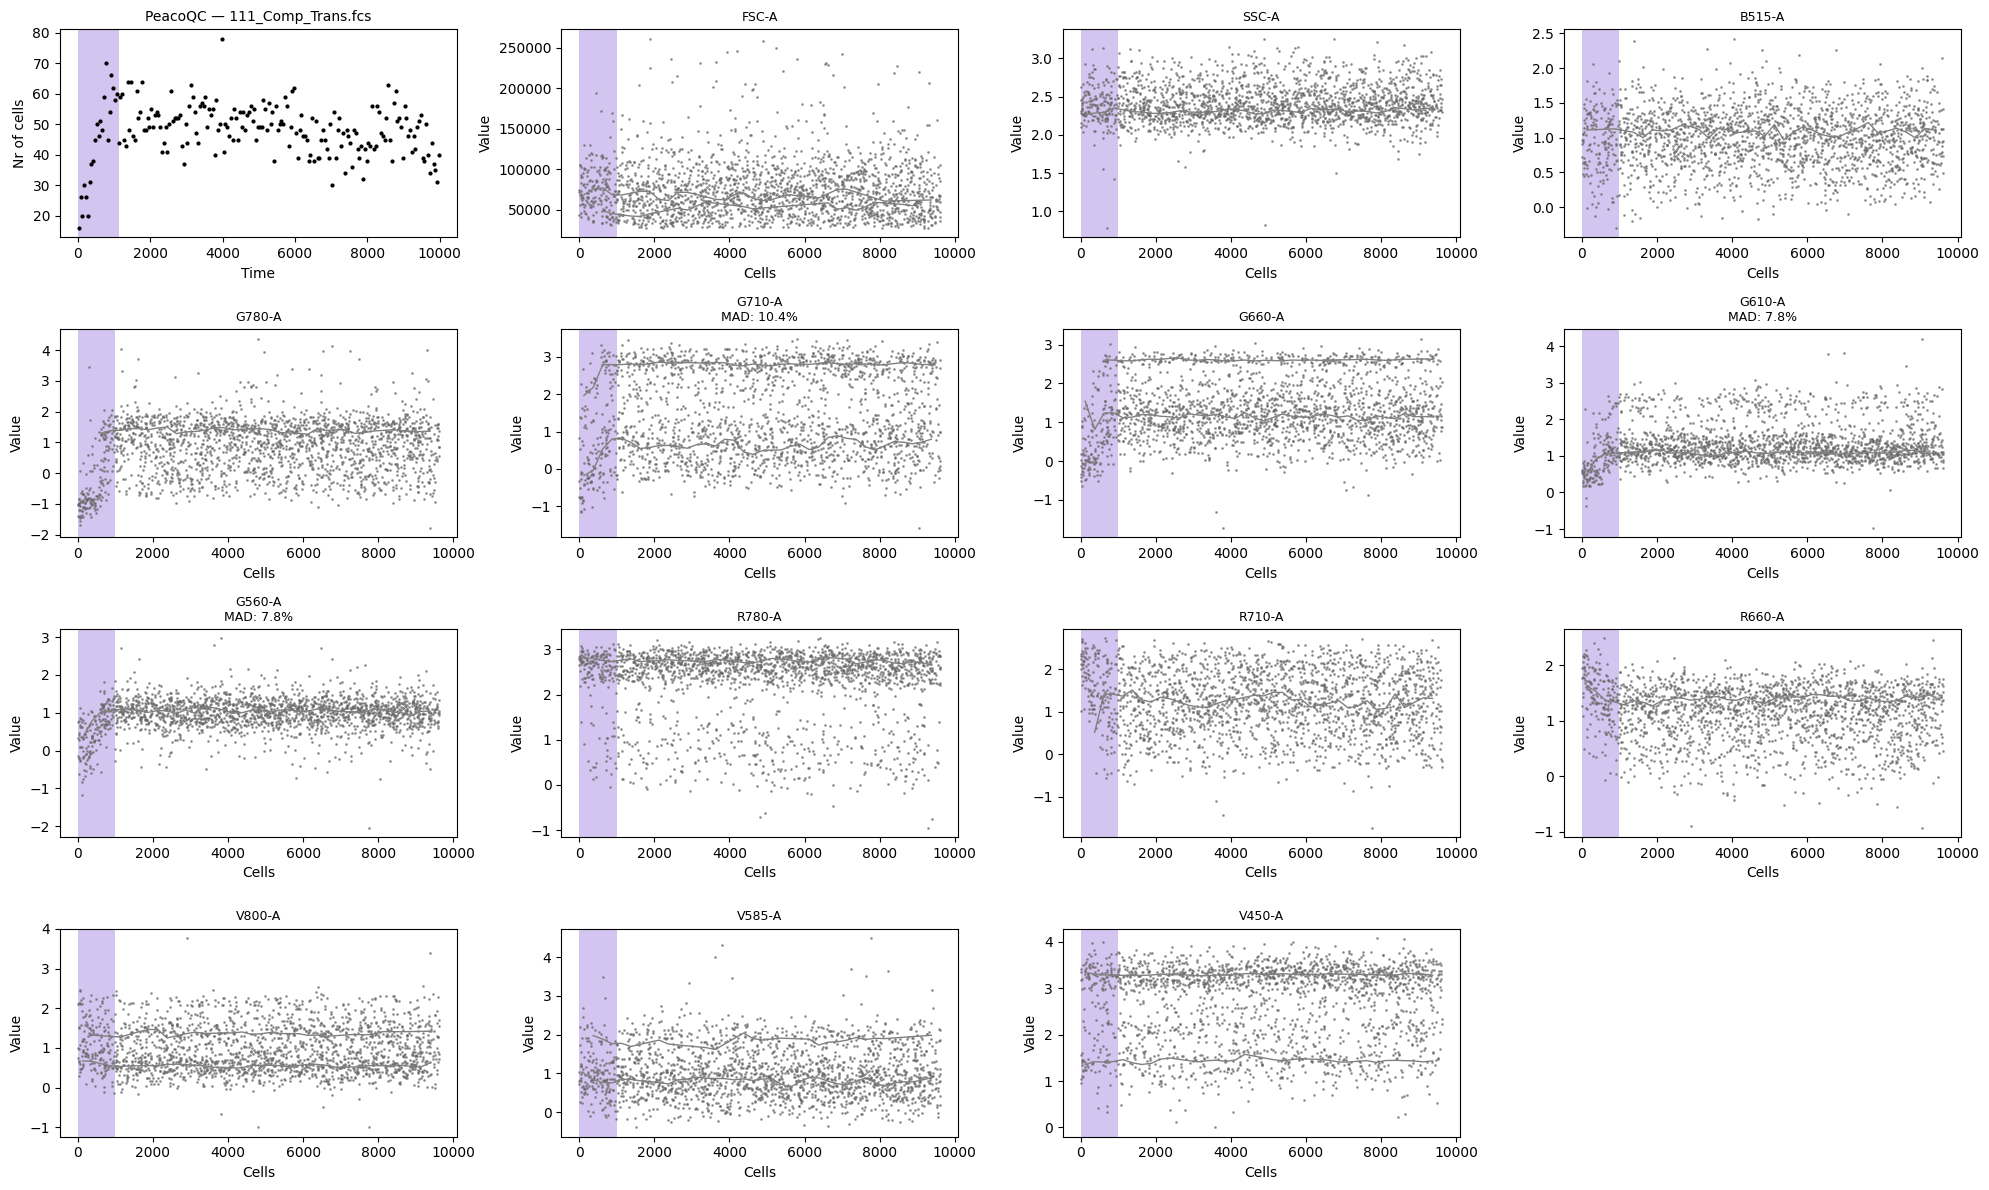

In [6]:
fig = peacoqc.plot_peaco_qc(
    adata,
    result,
    channels=channels,
    output_path=str(OUTPUT_DIR / "111_Comp_Trans_qc.png"),
    title="PeacoQC — 111_Comp_Trans.fcs",
)
plt.show()

## Mass cytometry data

For mass cytometry data the R vignette recommends a few parameter
tweaks, and all of them apply equally to this port:

* `remove_zeros=True` — mass cytometry channels are very sparse, so
  zero counts should not count as peaks.
* `it_limit` between `0.6` and `0.65` — slightly stricter than the
  flow-cytometry default because of the sparser channels.
* Margin removal and compensation are usually unnecessary.

A full mass cytometry example would look like:

```python
import peacoqc
import pytometry  # or flowutils — for the arcsinh transform

adata = peacoqc.read_fcs("mass_cytometry_sample.fcs")
mass_channels = [0, 2] + list(range(5, 53))
mass_channel_names = [adata.var_names[i] for i in mass_channels]

# Transform with cofactor 5 — no compensation needed.
adata.X[:, mass_channels] = np.arcsinh(adata.X[:, mass_channels] / 5.0)

result = peacoqc.peaco_qc(
    adata,
    channels=mass_channel_names,
    determine_good_cells="all",
    remove_zeros=True,
    it_limit=0.60,
)
```

This notebook does not execute the block above because no mass
cytometry fixture ships with the package — it is left as a template.

## Large datasets — parameter tuning

For a large batch of files the R vignette recommends tuning the QC
parameters on a handful of samples first, then processing the full
set in a loop. The key knobs are:

* ``mad`` — the MAD threshold. **Lower** values are stricter (more
  events removed). The R default of `6` matches this port.
* ``it_limit`` — the IsolationForest anomaly-score threshold.
  **Higher** values are stricter.
* ``force_it`` — the minimum number of bins required before the IT
  step runs at all (the upstream R default of 150 is preserved here).

The example file produces only 38 bins with the default
`events_per_bin=500`, so the IT step is skipped; only MAD and the
consecutive-bin cleanup run. We illustrate tuning by re-running
with a stricter MAD threshold.

In [7]:
# Re-run with a stricter MAD threshold (lower = more aggressive),
# appending to the same CSV report so peaco_qc_heatmap (below) can
# show both runs side by side.
result_strict = peacoqc.peaco_qc(
    adata,
    channels=channels,
    determine_good_cells="all",
    mad=4,
    report_path=str(report_path),
)

print(f"{'':25s} {'default':>12s} {'mad=4':>12s}")
print(f"{'total removed (%)':25s} "
      f"{result.percentage_removed:12.2f} "
      f"{result_strict.percentage_removed:12.2f}")
print(f"{'IT (%)':25s} "
      f"{result.it_percentage!s:>12s} "
      f"{result_strict.it_percentage!s:>12s}")
print(f"{'MAD (%)':25s} "
      f"{result.mad_percentage:12.2f} "
      f"{result_strict.mad_percentage:12.2f}")
print(f"{'consecutive (%)':25s} "
      f"{result.consecutive_percentage:12.2f} "
      f"{result_strict.consecutive_percentage:12.2f}")

                               default        mad=4
total removed (%)                10.40        16.81
IT (%)                            None         None
MAD (%)                          10.40        16.81
consecutive (%)                   0.00         0.00


Once the parameters are tuned, processing a batch of files is a
plain Python loop. Every run is appended to the CSV report so that
`peaco_qc_heatmap` can visualise them all at once:

```python
for fcs_path in sorted(my_fcs_dir.glob("*.fcs")):
    adata = peacoqc.read_fcs(str(fcs_path))
    adata = peacoqc.remove_margins(adata, channels=channels)
    result = peacoqc.peaco_qc(
        adata,
        channels=channels,
        determine_good_cells="all",
        it_limit=0.65,
        report_path="peacoqc_report.csv",  # appended to
    )
    peacoqc.plot_peaco_qc(
        adata, result, channels=channels,
        output_path=f"qc_plots/{fcs_path.stem}.png",
    )
    peacoqc.write_fcs(result.adata, f"clean/{fcs_path.stem}.fcs")
```

To make the MAD step stricter pass a lower `mad` value (the R
vignette used `MAD=8`); to make it looser pass a higher one.

## Multi-sample report: `peaco_qc_heatmap`

`peaco_qc_heatmap` reads either the CSV produced by
`peaco_qc(..., report_path=...)` or the tab-separated
`PeacoQC_report.txt` shipped by the R package, and renders a
removal-percentage heatmap with the per-row QC parameters on the
left and a directional-trend column on the right.

First, the heatmap for the CSV report we just wrote (two runs on the
same file):

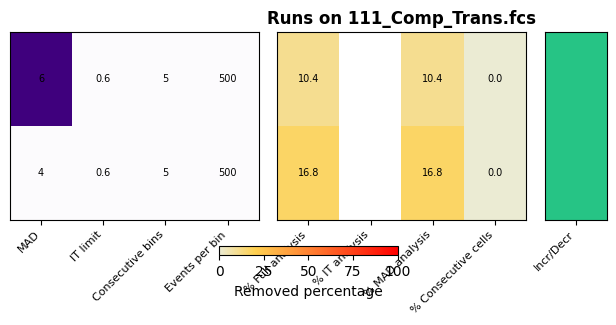

In [8]:
fig = peacoqc.peaco_qc_heatmap(
    str(report_path),
    title="Runs on 111_Comp_Trans.fcs",
    show_values=True,
    output_path=str(OUTPUT_DIR / "heatmap_own_runs.png"),
)
plt.show()

`peaco_qc_heatmap` also reads the legacy tab-separated report
generated by the R package. The file
`inst/extdata/PeacoQC_report.txt` that ships with the repo contains
62 runs across several conditions:

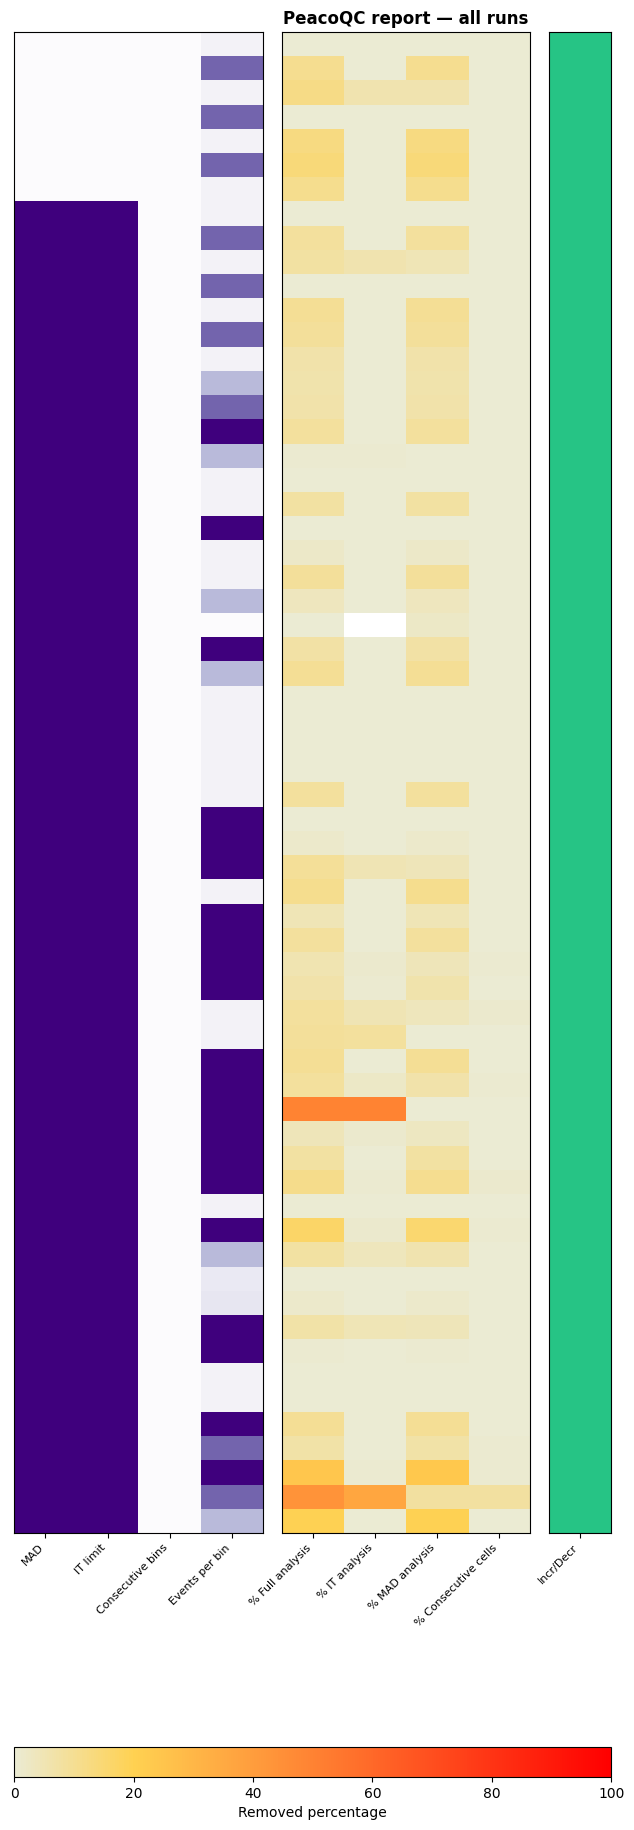

In [9]:
fig = peacoqc.peaco_qc_heatmap(
    str(R_REPORT),
    show_values=False,
    show_row_names=False,
    title="PeacoQC report — all runs",
    output_path=str(OUTPUT_DIR / "heatmap_all_runs.png"),
)
plt.show()

With `latest_tests=True` the heatmap keeps only the most recent run
per filename — the Python equivalent of the R vignette's
`latest_tests=TRUE`:

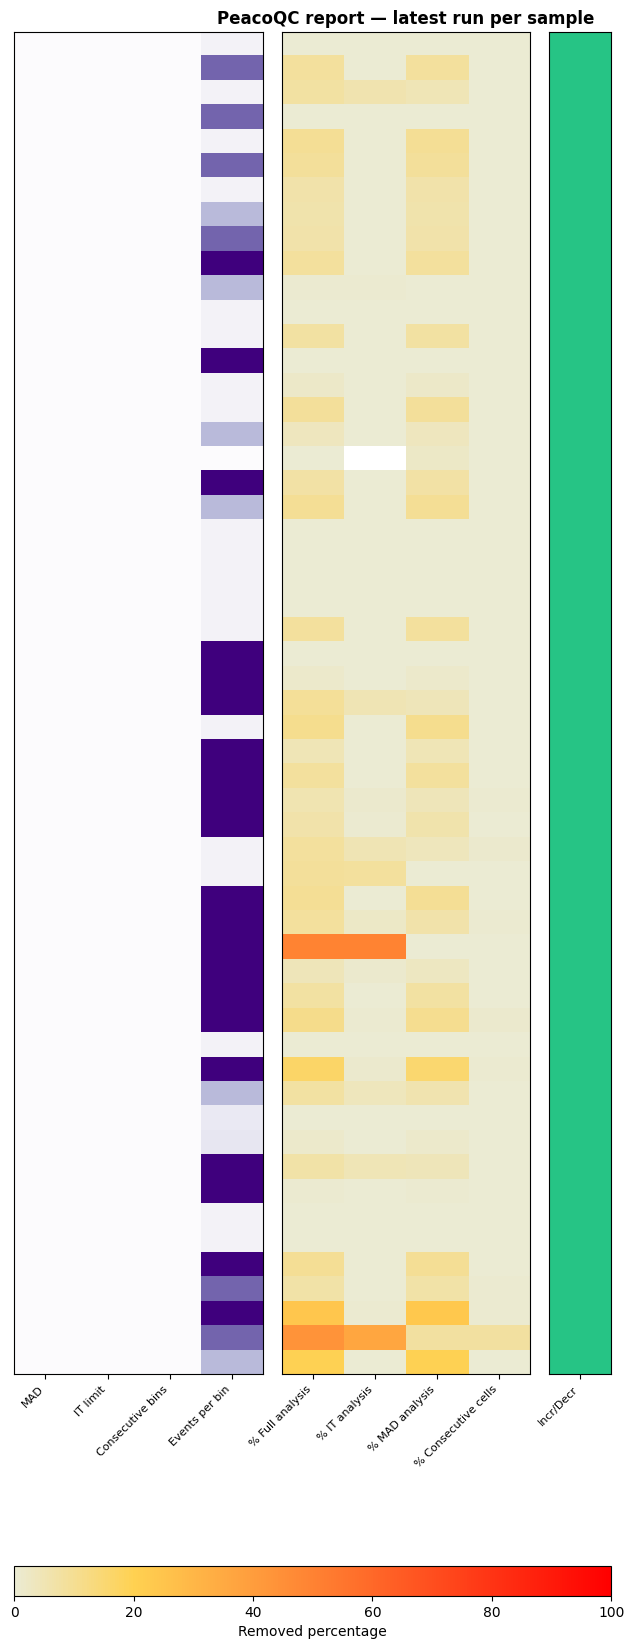

In [10]:
fig = peacoqc.peaco_qc_heatmap(
    str(R_REPORT),
    show_values=False,
    show_row_names=False,
    latest_tests=True,
    title="PeacoQC report — latest run per sample",
    output_path=str(OUTPUT_DIR / "heatmap_latest.png"),
)
plt.show()

> **Divergence from R:** the R `PeacoQCHeatmap` supports a
> `row_split` parameter (via the underlying `ComplexHeatmap`). The
> Python port does not currently expose row splitting — group your
> rows upstream (e.g., by writing several reports, or by editing the
> `Filename` column) and call `peaco_qc_heatmap` per group.

## Peak-only inspection (equivalent of `PlotPeacoQC`)

The R vignette uses `PlotPeacoQC(ff, channels, display_peaks=TRUE)`
to visualise per-channel peak trajectories without actually removing
any events. In the Python port the same behaviour is obtained by
running `peaco_qc` with `determine_good_cells=False` (which skips
the IT and MAD outlier steps) and feeding the result into
`plot_peaco_qc`:

analysis mode      : none
percentage removed : 0.0
peak frames        : ['FSC-A', 'SSC-A', 'B515-A'] ...


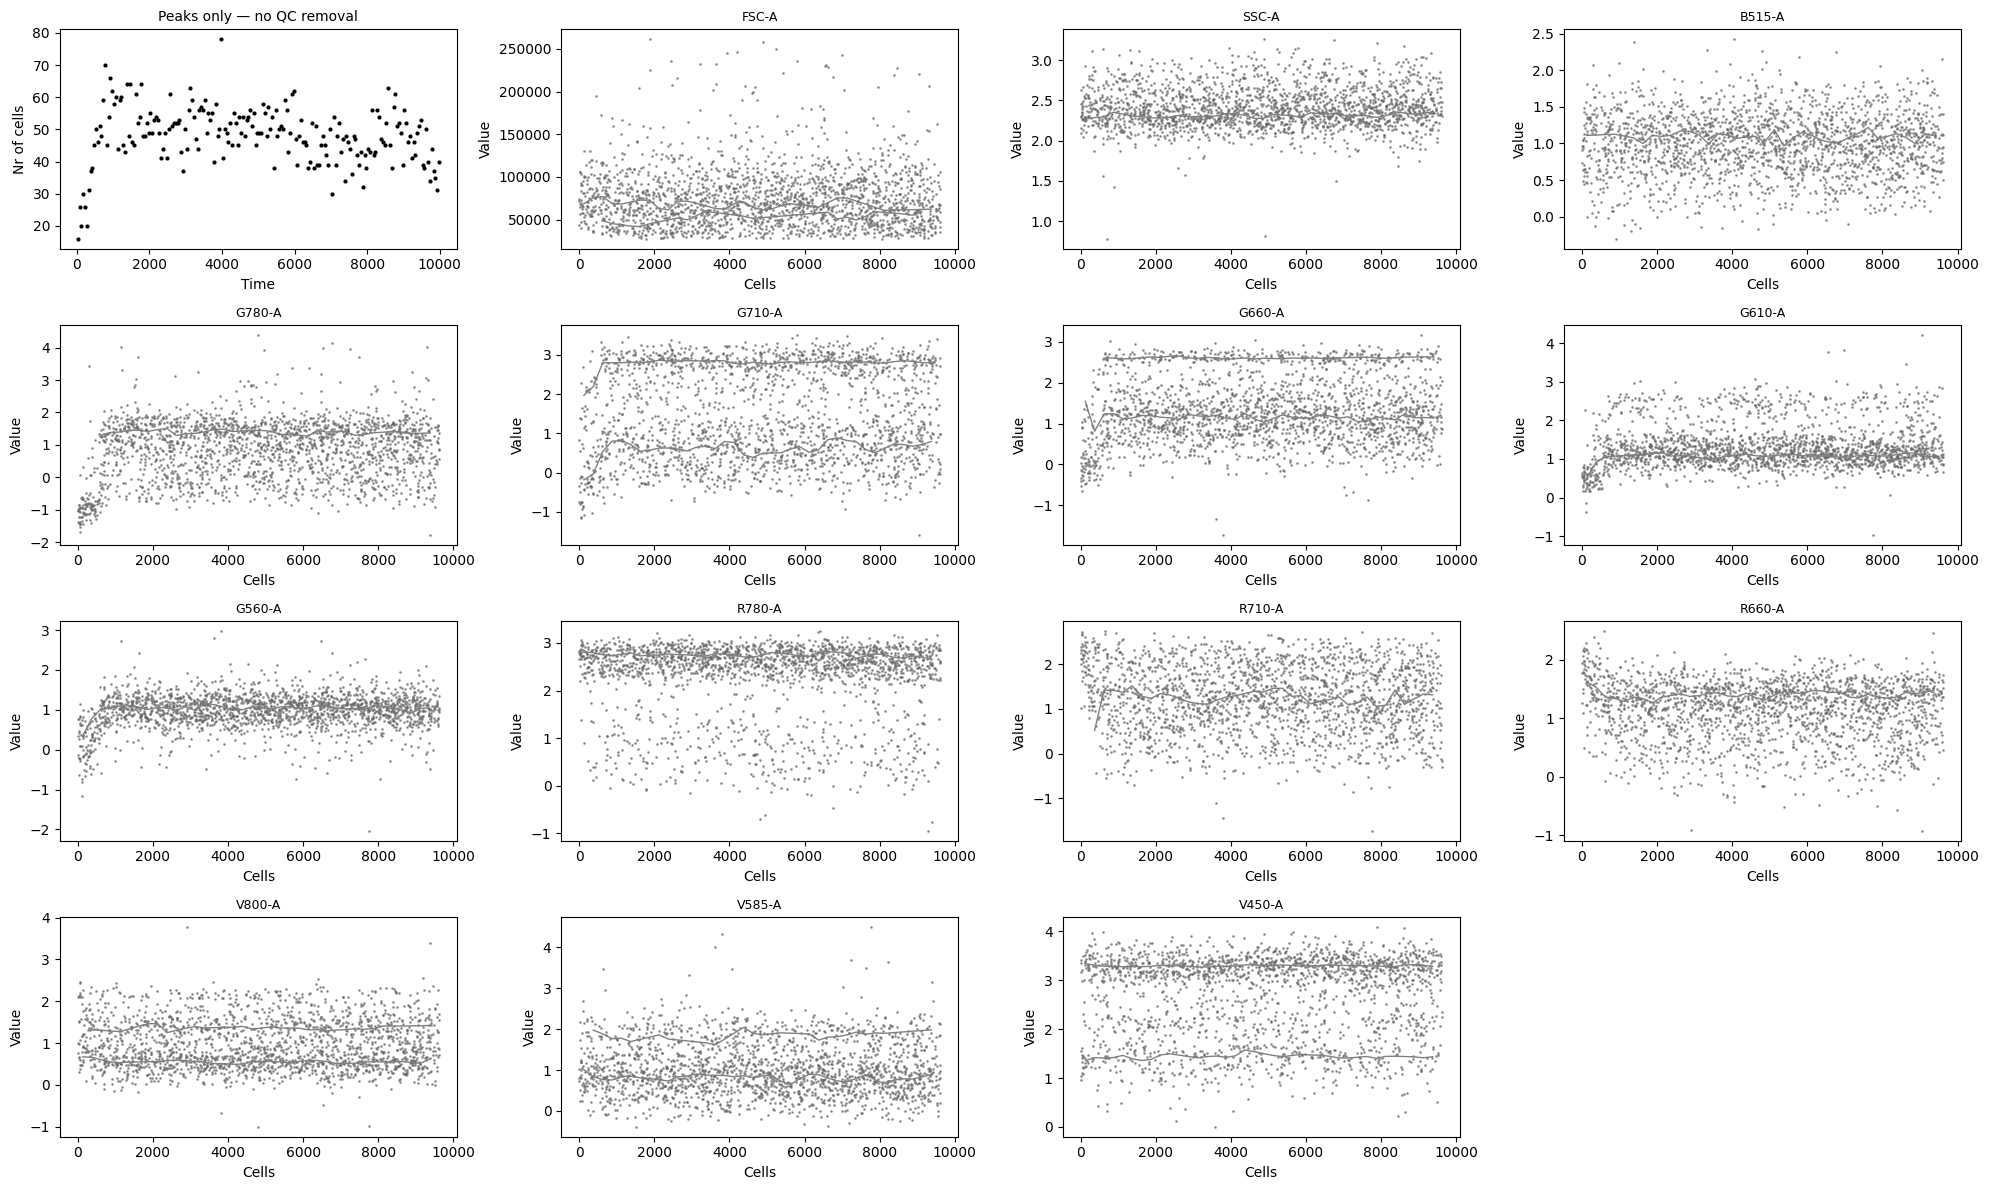

In [11]:
peaks_only = peacoqc.peaco_qc(
    adata,
    channels=channels,
    determine_good_cells=False,
)
print(f"analysis mode      : {peaks_only.analysis}")
print(f"percentage removed : {peaks_only.percentage_removed}")
print(f"peak frames        : {list(peaks_only.peaks)[:3]} ...")

fig = peacoqc.plot_peaco_qc(
    adata,
    peaks_only,
    channels=channels,
    title="Peaks only — no QC removal",
    output_path=str(OUTPUT_DIR / "peaks_only.png"),
)
plt.show()

## Next steps

* Consult the [API reference](api.rst) for the full signature and
  parameter list of every public function.
* See the [upstream R package vignette](https://bioconductor.org/packages/release/bioc/vignettes/PeacoQC/inst/doc/PeacoQC.html)
  for the original methodology paper and parameter intuition.
* Follow the [installation guide](installation.rst) for development
  installs and optional extras.